                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

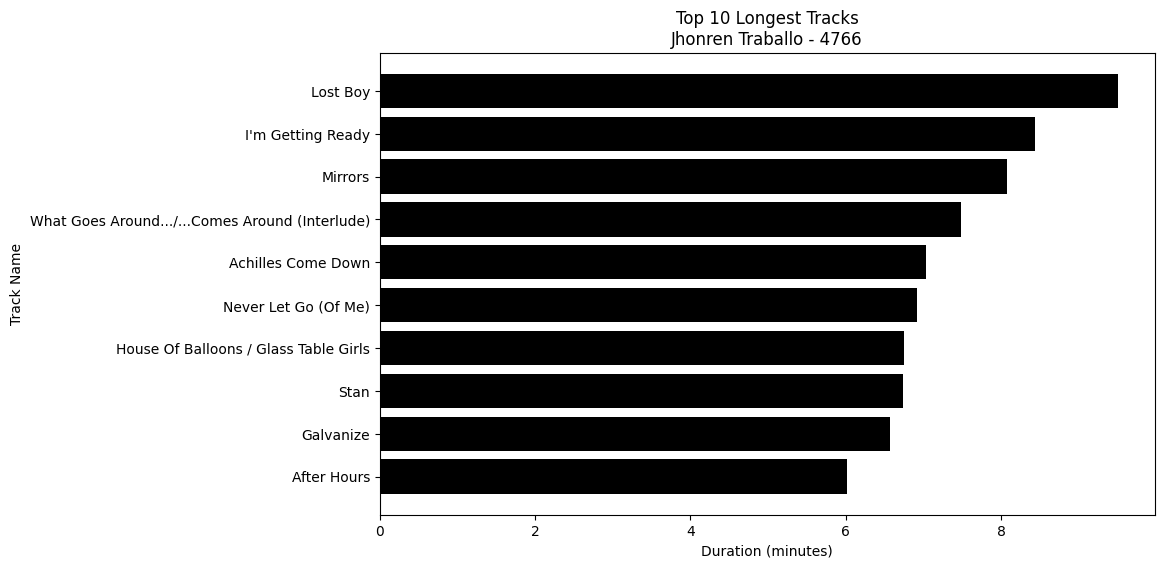

In [3]:
# 1. Identify Longest Tracks

import pandas as pd
import matplotlib.pyplot as plt

# --- Input ---
df = pd.read_csv("spotify_top_1000_tracks.csv") 

# Student-specific parameters
student_name = "Jhonren Traballo"
student_id = "4766"
color_bar = "Black"

# --- Calculations ---
# Sort dataset by duration in descending order
longest_tracks = df.sort_values(by="duration_min", ascending=False).head(10)

# --- Output ---
print(longest_tracks[['track_name', 'artist', 'duration_min']])

# Horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(longest_tracks['track_name'], longest_tracks['duration_min'], color=color_bar)
plt.xlabel("Duration (minutes)")
plt.ylabel("Track Name")
plt.title(f"Top 10 Longest Tracks\n{student_name} - {student_id}")
plt.gca().invert_yaxis()  # longest at top
plt.show()

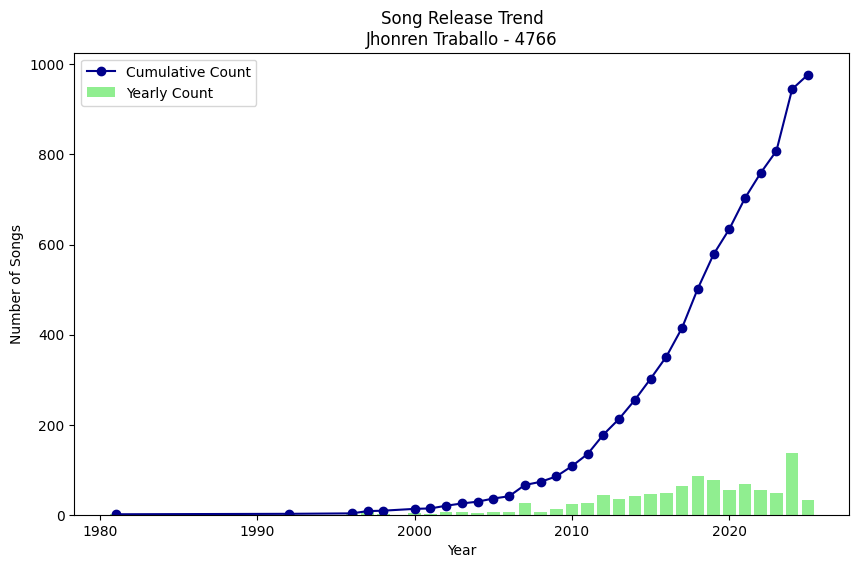

In [7]:
# 2. Song Release Trend

# --- Functionality ---
# Visualize the number of songs released per year with a combined line and bar chart.

import pandas as pd
import matplotlib.pyplot as plt

# --- Input ---
color_bar = "lightgreen"
color_line = "darkblue"

# --- Calculations ---
# Extract year from release_date column
# If release_date is in format YYYY-MM-DD, this works:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Group dataset by year and count songs
yearly_counts = df.groupby("year").size().reset_index(name="count")
yearly_counts["cumulative"] = yearly_counts["count"].cumsum()

# --- Output ---
fig, ax = plt.subplots(figsize=(10,6))

# Bar chart for yearly counts
ax.bar(yearly_counts["year"], yearly_counts["count"], color=color_bar, label="Yearly Count")

# Line chart for cumulative counts
ax.plot(yearly_counts["year"], yearly_counts["cumulative"], color=color_line, marker="o", label="Cumulative Count")

ax.set_xlabel("Year")
ax.set_ylabel("Number of Songs")
ax.set_title(f"Song Release Trend\n{student_name} - {student_id}")
ax.legend()
plt.show()


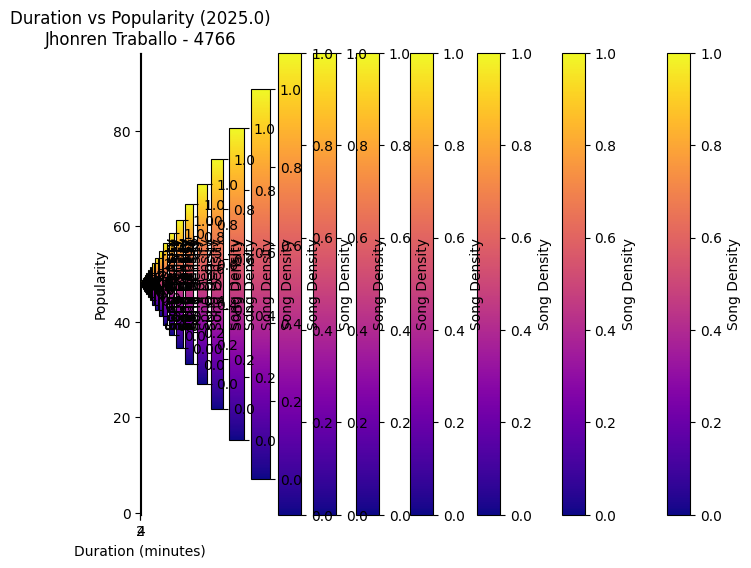

In [ ]:
# 3. Animated Density Map of Duration vs Popularity

# --- Functionality ---
import matplotlib.animation as animation

# --- Input ---
# Columns used: duration_min, popularity, year
cmap_color = "plasma"

# --- Calculations ---
years = sorted(df['year'].unique())

fig, ax = plt.subplots(figsize=(8,6))

def update(year):
    ax.clear()
    subset = df[df['year'] == year]
    hb = ax.hexbin(subset['duration_min'], subset['popularity'], gridsize=30, cmap=cmap_color)
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('Song Density')
    ax.set_title(f"Duration vs Popularity ({year})\n{student_name} - {student_id}")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Popularity")

# --- Output ---
ani = animation.FuncAnimation(fig, update, frames=years, repeat=False)
ani.save("animated_density_map.gif", writer="pillow")  # saves as GIF
plt.show()
